# **A1: EY Urban Heat Islands (UHI) Challenge - Freetown, Sierra Leone (Classification Modeling)**
### Business Challenge II | AI & Analytics Challenge | BCH-7820 | BMBANDD1
#### By: **Team 5**
- Eduardo Vadillo Polo
- Fenja BARTELS
- Luis Vincent SCHROPP
- Nolan Pierce
- Renan PERES
- Tyler Lyon

<br>

<br>

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<div style="display: flex; gap: 8px;">

  <img src="https://ontheworldmap.com/sierra-leone/city/freetown/freetown-location-on-the-sierra-leone-map.jpg"
       alt="Freetown"
       width="600" />

  <img src="https://southafrica-info.com/wp-content/uploads/2018/03/Freetown_Sierra_Leone_890.jpg"
       alt="Sierra Leone"
       width="950" />

</div>

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />


## **I. Introduction to the Challenge**

The objective of this analysis is to develop a machine learning model that can predict Urban Heat Island intensity at a micro scale, identify spatial hotspots, and present actionable insights for urban planners to protect global communities from this intensifying problem.

Urban Heat Islands are a well-researched phenomenon in which parts of cities become significantly hotter than their surroundings, in some cases by more than 10°C, mainly driven by rapid urbanization and the spread of heat-absorbing surfaces (Srivastava et al., 2024).

At a human level, this is a significant health risk for anyone in these areas. The effects of these heat islands range from milder impacts, such as poor sleep and reduced productivity, to more severe outcomes, with urban heat islands linked to 4% of summer deaths in major cities (ISGlobal, 2023).

#### **Notebook objective** 

This notebook builds a machine learning model to classify Urban Heat Island (UHI) intensity from Sentinel-2 satellite data and building footprint data. In addition, band- and weather-related features were utilized to build our model and improve its performance. The goal was to learn patterns from Santiago, Chile, and Rio de Janeiro, Brazil, and apply them to predict UHI classes (Low, Medium, High) in the unseen validation city of Freetown, Sierra Leone.

Multiple machine learning models were tested and evaluated using macro F1-score, which was the primary UHI classification metric for this challenge. **The final classification model, `LGBM (Resampled)`, achieved an F1 score of 0.46** in predicting the UHI classes in Freetown.

<br>

#### **Current Model Limitations**
The model includes a limited feature set and relies on a single validation split, so its measured performance may not fully reflect how well it would generalize under different conditions. While the final model performed better after feature expansion and resampling, it still depends heavily on surface-level and thermal variables derived from remote sensing data, which cannot fully capture the complexity of urban environments. Important explanatory factors such as building height, road density, land use, population density, and temporal variation in heat conditions were not included, which likely constrained predictive accuracy.

In addition, the model was trained on data from Santiago and Rio and then transferred to Freetown, meaning that differences in climate, urban structure, and class distribution may still introduce geographic bias. The resampling strategy improved alignment with the expected class balance in Freetown, but it also introduces assumptions about the target distribution that may not hold perfectly across all locations. As a result, the model should be interpreted as a strong first approximation rather than a fully comprehensive representation of UHI dynamics, and further feature engineering, validation, and calibration would likely lead to better results.


## **II. Recommendations**

#### **Recommendation 1**

Based on our analysis, the factor that contributed most to predicting urban heat islands was Land Surface Temperature (LST) and emissivity derived from Landsat satellite imagery. In practical terms, this means that areas with more impervious surfaces, such as concrete and asphalt, tend to absorb and retain significantly more heat throughout the day.
What makes this factor particularly important is that it directly affects how much heat is stored versus reflected. For example, surfaces with low emissivity values absorb more radiation and release it slowly, which leads to higher temperatures even after sunset. This aligns with the general observation that urban environments without natural cooling mechanisms tend to trap heat more intensely.
Another reason this factor stands out is that it is consistently visible across different areas in the dataset, making it a reliable predictor rather than a one-off pattern. It also helps explain why certain neighborhoods experience stronger heat effects than others, even within the same city.
Overall, this insight is valuable because it translates a complex model outcome into something very tangible: the less natural cooling a space has, the hotter it becomes, which can directly inform urban planning decisions.

#### **Recommendation 2**

Our analysis suggests that there are several practical solutions that can have a significant impact. One key approach is reducing overall heat absorption on pavement, asphalt, and buildings. For example, painting rooftops with light, highly reflective colors can reduce heat absorption and cool buildings, which can reduce surrounding air temperature by 3-10°F (Wesley et al.). This is a great method for developing states, as it is scalable and low-cost.
Additionally, incorporating natural ventilation and shading when constructing buildings will decrease temperature both inside the building, by creating airflow, and outside, by creating urban ventilation corridors. This is key for countries that do not rely heavily on air conditioning, as it has the potential to reduce temperatures by 3.3°C to 5.9°C (World Bank).
Finally, cities can immediately begin to reduce UHI by increasing the number of shaded public spaces through covered bus stops, walkways, and building access points. This can be done through locally sourced material at a low cost to governments, providing quick protection from the sun and protecting people who are most at risk of overheating.

#### **Recommendation 3**

Given more time, one of the most valuable additions to our model would be building height and volume data, as urban heat dynamics are strongly influenced by physical urban structure beyond what satellite imagery alone can capture. For example, tall buildings create urban canyon effects that trap heat and reduce airflow, which would provide a more complete picture of how heat behaves in urban areas.
Another important data point would be population density and road network density, since the physical structure of a city plays a major role in heat accumulation and retention. This would help the model better distinguish between different types of urban environments.
We also believe that incorporating temporal multi-date composites and time-series temperature data would significantly improve prediction accuracy. Urban heat is not static, and understanding how it changes over time would allow for more dynamic and realistic modeling.
Importantly, all of these datasets are already publicly available through sources such as NASA, OpenStreetMap, the Global Human Settlement Layer, and the 3D-GloBFP dataset, making them feasible additions to future iterations of the model.
Overall, adding these data sources would move the model from a primarily surface-level prediction tool to a more comprehensive system that captures the full complexity of urban heat dynamics.


## **III. Key Analysis and Code**

#### Set Up & Imports

In [ ]:
%pip install --quiet --upgrade rioxarray pystac_client planetary_computer odc-stac lightgbm xgboost tqdm geopandas

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_bounds
import rioxarray as rxr
import geopandas as gpd
from shapely.geometry import Point, box
from pyproj import Transformer
import pystac_client
import planetary_computer as pc
from odc.stac import stac_load
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

#### Configuration

In [ ]:
lakehouse_path = "/lakehouse/default/Files/"
OUTPUT_PATH    = f"{lakehouse_path}/Predictions"

workspace_id   = "YOUR_WORKSPACE_ID"
lakehouse_id   = "YOUR_LAKEHOUSE_ID"
spark_data_path = f"abfss://{workspace_id}@onelake.dfs.fabric.microsoft.com/{lakehouse_id}/Files/combined_uhi_data.csv"

chile_csv_url  = "https://raw.githubusercontent.com/chase-kusterer/bc-II/refs/heads/main/Data/sample_chile_uhi_data.csv"
brazil_csv_url = "https://raw.githubusercontent.com/chase-kusterer/bc-II/refs/heads/main/Data/sample_brazil_uhi_data.csv"
test_csv_url   = "https://raw.githubusercontent.com/chase-kusterer/bc-II/refs/heads/main/Data/validation_dataset.csv"

chile_shp  = f"{lakehouse_path}/Chile Building Footprints/Chile_clipped.shp"
brazil_shp = f"{lakehouse_path}/Brazil Building Footprints/Brazil_clipped.shp"
sierra_shp = f"{lakehouse_path}/Sierra Leone Building Footprints/Sierra Leone_clipped.shp"

label_map  = {0: "Low", 1: "Medium", 2: "High"}

os.makedirs(OUTPUT_PATH, exist_ok=True)

#### Load Combined Dataset

In [ ]:
uhi_data_spark = (
    spark.read.format("csv")
    .option("header", "true")
    .option("inferSchema", "true")
    .load(spark_data_path)
)
uhi_data = uhi_data_spark.toPandas()
print(f"Combined dataset shape: {uhi_data.shape}")

display(uhi_data.head())

#### Feature Extraction Functions

In [ ]:
def extract_band_values(geotiff_path, csv_input_path):
    """
    Extracts NDVI, NDBI, NDWI from a single-scene TBR GeoTIFF.
    Used for Model 1 (Chile) and Model 2 (Rio).
    """
    data     = rxr.open_rasterio(geotiff_path)
    tiff_crs = data.rio.crs

    df         = pd.read_csv(csv_input_path)
    latitudes  = df['Latitude'].values
    longitudes = df['Longitude'].values

    transformer = Transformer.from_crs("EPSG:4326", tiff_crs, always_xy=True)
    xs, ys      = transformer.transform(longitudes, latitudes)

    coords  = {"x": ("points", xs), "y": ("points", ys)}
    sampled = data.interp(coords, method="nearest")

    df["median_NDVI"] = sampled.sel(band=1).values
    df["median_NDBI"] = sampled.sel(band=2).values
    df["median_NDWI"] = sampled.sel(band=3).values

    return df


def compute_building_density(
    csv_path,
    buildings_shp_path,
    lat_col="Latitude",
    lon_col="Longitude",
    buffer_m=100,
    n_jobs=None,
):
    """
    Computes building density within a 100m square buffer.
    Uses spatial indexing for fast computation.
    """
    df       = pd.read_csv(csv_path)
    geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
    gdf_points = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326").to_crs(epsg=3857)

    gdf_buildings = gpd.read_file(buildings_shp_path).to_crs(epsg=3857)
    gdf_buildings['geometry'] = gdf_buildings.geometry.buffer(0)
    gdf_buildings = gdf_buildings[
        gdf_buildings.geometry.notnull() & ~gdf_buildings.geometry.is_empty
    ].copy()

    sindex      = gdf_buildings.sindex
    half_buffer = buffer_m / 2.0
    area_m2     = float(buffer_m * buffer_m)

    if n_jobs is None:
        n_jobs = max(1, (os.cpu_count() or 2) - 1)

    def density_for_idx(i):
        point_geom = gdf_points.geometry.iloc[i]
        minx = point_geom.x - half_buffer
        miny = point_geom.y - half_buffer
        maxx = point_geom.x + half_buffer
        maxy = point_geom.y + half_buffer

        candidate_idx = list(sindex.intersection((minx, miny, maxx, maxy)))
        if not candidate_idx:
            return 0.0

        buffer_geom     = box(minx, miny, maxx, maxy)
        candidate_geoms = gdf_buildings.geometry.iloc[candidate_idx]
        bldg_count      = int(candidate_geoms.intersects(buffer_geom).sum())
        return bldg_count / area_m2

    total_points = len(gdf_points)
    use_parallel = n_jobs > 1 and total_points > 500

    if use_parallel:
        with ThreadPoolExecutor(max_workers=n_jobs) as executor:
            densities = list(tqdm(
                executor.map(density_for_idx, range(total_points), chunksize=200),
                total=total_points,
                desc="Building density"
            ))
    else:
        densities = [
            density_for_idx(i)
            for i in tqdm(range(total_points), desc="Building density")
        ]

    gdf_points['building_density_100m'] = densities
    return gdf_points

#### Evaluation Helper

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, labels):
    """
    Prints classification report and plots confusion matrix.
    """
    # In-sample
    train_preds = model.predict(X_train)
    train_acc   = accuracy_score(y_train, train_preds)
    train_f1    = f1_score(y_train, train_preds, average='macro')

    # Out-of-sample
    test_preds = model.predict(X_test)
    test_acc   = accuracy_score(y_test, test_preds)
    test_f1    = f1_score(y_test, test_preds, average='macro')

    print(f"\n{'='*55}")
    print(f"Model: {model_name}")
    print(f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")
    print(f"Train Macro F1: {train_f1:.4f} | Test Macro F1: {test_f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, test_preds))

    # Confusion matrix
    cm   = confusion_matrix(y_test, test_preds, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues')
    plt.title(f'{model_name} — Confusion Matrix')
    plt.grid(False)
    plt.show()

    return test_preds, test_f1

### **Model Training: Santiago, Chile**

For the Santiago model, our initial approach was grounded in the physical drivers of urban heat islands. We selected NDVI, NDBI, and NDWI as our core spectral features because they directly capture the three surface conditions most associated with UHI intensity: vegetation cover, built-up density, and water presence, respectively. Building density at a 100 m buffer was added to represent neighborhood-scale urban structure, since heat accumulation is fundamentally a local phenomenon driven by how densely buildings are packed together. We complemented these with weather variables, temperature, humidity, wind speed, and wind gusts, drawn from Open-Meteo, reasoning that microclimatic conditions play a direct role in how heat is retained or dispersed across urban areas. Altitude was included given Santiago's unique topography, as elevation influences both temperature gradients and atmospheric pressure. Random Forest was chosen as our reference model due to its ability to handle mixed feature types and its interpretability through feature importance.


#### Filter Chile from combined dataset

In [ ]:
country_coordinates = pd.read_csv(f"https://raw.githubusercontent.com/chase-kusterer/bc-II/refs/heads/main/Data/sample_chile_uhi_data.csv")

chile_uhi_data = uhi_data.merge(country_coordinates,
    how='inner',
    on=['Latitude', 'Longitude']
)

chile_uhi_data = chile_uhi_data.iloc[:, :-1].rename(columns={'UHI_Class_x': 'UHI_Class'})
# chile_uhi_data.head()

#### Feature selection

In [ ]:
cols_to_drop = [
    'rain', 'showers', 'snowfall',
    'image_datetime', 'surface_pressure', 'pressure_msl',
    'building_density_10m', 'building_density_20m', 'building_density_50m'
]

chile_uhi_data_clean = chile_uhi_data.drop(columns=cols_to_drop, errors='ignore')

train = chile_uhi_data_clean.loc[:, [
    'median_NDVI', 'median_NDBI', 'median_NDWI',
    'building_density_100m',
    'temperature_2m', 'wind_speed_10m', 'relative_humidity_2m',
    'wind_gusts_10m', 'wind_direction_10m',
    'altitude_m'
] + ['UHI_Class']]

print(f"Shape: {train.shape}")
print(train['UHI_Class'].value_counts())

#### Train/test split

In [ ]:
X = train.drop(columns=['UHI_Class']).values.astype(float)
y = train['UHI_Class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=123
)

print(f"X_train shape: {X_train.shape}")
print(f"Class distribution - train: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Class distribution - test: {pd.Series(y_test).value_counts().to_dict()}")

#### Feature Scaling (Standardization)

In [ ]:
sc_chile = StandardScaler()
X_train  = sc_chile.fit_transform(X_train)
X_test   = sc_chile.transform(X_test)

#### Model Training (Random Forest)

In [ ]:
rf_chile = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=6,
    max_features='sqrt',
    random_state=42,
)

rf_chile.fit(X_train, y_train)

#### Model Evaluation (Testing)

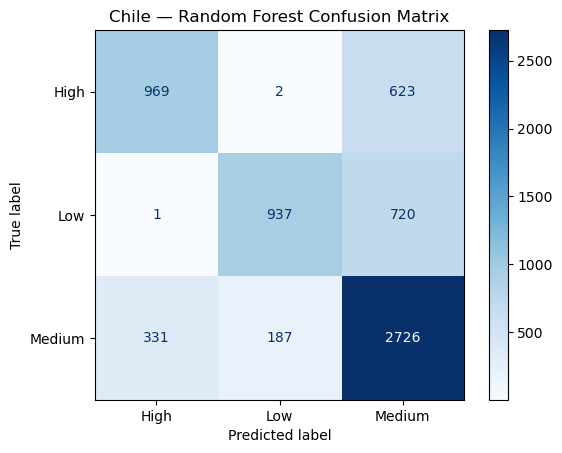

In [12]:
train_preds = rf_chile.predict(X_train)
test_preds  = rf_chile.predict(X_test)

print(f"Train Acc: {accuracy_score(y_train, train_preds):.4f} | Test Acc: {accuracy_score(y_test, test_preds):.4f}")
print(f"Train F1:  {f1_score(y_train, train_preds, average='weighted'):.4f} | Test F1: {f1_score(y_test, test_preds, average='weighted'):.4f}")
print(f"\nTest Classification Report:")
print(classification_report(y_test, test_preds))

# Confusion matrix
cm   = confusion_matrix(y_test, test_preds, labels=np.unique(y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues')
plt.title("Chile — Random Forest Confusion Matrix")
plt.grid(False)
plt.show()

#### Feature importance

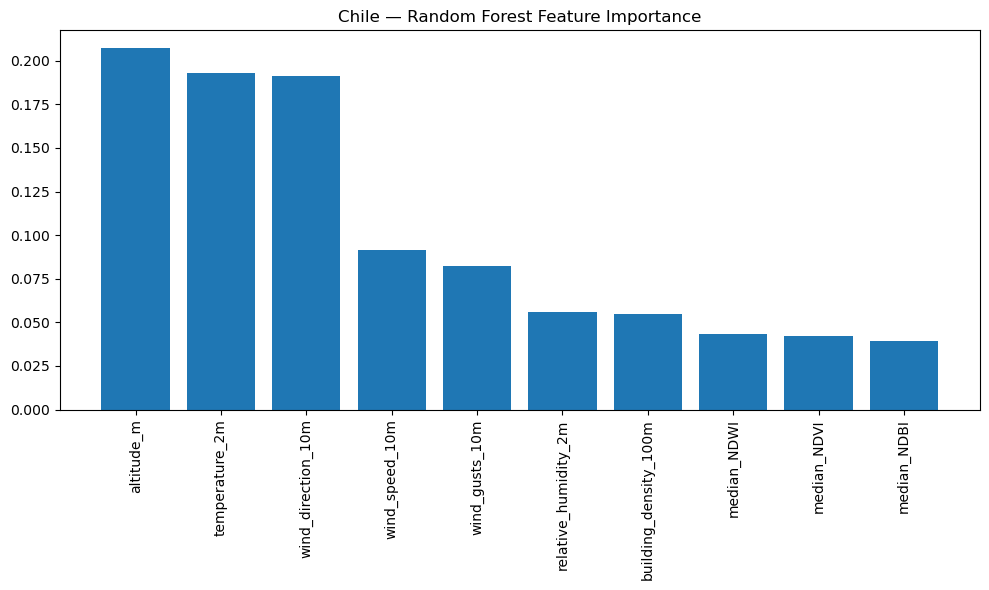

In [13]:
feature_names = train.drop(columns=['UHI_Class']).columns
importances   = rf_chile.feature_importances_
indices       = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Chile — Random Forest Feature Importance")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

#### Save Predictions
> `Predicted_Dataset_Santiago.csv`

In [ ]:
chile_feature_cols = train.drop(columns=['UHI_Class']).columns.tolist()
X_chile_full        = chile_uhi_data_clean[chile_feature_cols].values.astype(float)
X_chile_full_scaled = sc_chile.transform(X_chile_full)
chile_full_preds    = rf_chile.predict(X_chile_full_scaled)

pd.DataFrame({
    'Longitude': chile_uhi_data_clean['Longitude'].values,
    'Latitude':  chile_uhi_data_clean['Latitude'].values,
    'UHI_Class': chile_full_preds
}).to_csv(f"{OUTPUT_PATH}/Predicted_Dataset_Santiago.csv", index=False)

print("Saved: Predicted_Dataset_Santiago.csv")

### **Model Training: Rio de Janeiro, Brazil**

For the Rio model, we followed an identical approach: the same feature set, the same preprocessing pipeline, and the same model candidates. However, we were surprised to find that Gradient Boosting significantly outperformed Random Forest on the Rio dataset. This was one of the first major question marks we encountered in the project. We had no immediate explanation for why the same modeling approach would produce such different results across two cities using equivalent features and data structures. In hindsight, this likely pointed to something more fundamental: the two cities have very different class distributions, spectral signatures, and urban features, meaning that what the model was actually learning differed significantly between them. At the time, we noted the performance gap but did not fully appreciate what it implied: that our models were not learning universal UHI patterns, but rather city-specific ones. This would become the central challenge we faced when attempting to generalize to Freetown.


#### Filter Rio from combined dataset

In [ ]:
rio_coordinates = pd.read_csv("https://raw.githubusercontent.com/chase-kusterer/bc-II/refs/heads/main/Data/sample_brazil_uhi_data.csv")

rio_uhi_data = uhi_data.merge(rio_coordinates,
    how='inner', on=['Latitude', 'Longitude'])
rio_uhi_data = rio_uhi_data.iloc[:, :-1].rename(columns={'UHI_Class_x': 'UHI_Class'})

rio_uhi_data_clean = rio_uhi_data.drop(columns=cols_to_drop, errors='ignore')

# Use same features as Chile training
chile_feature_cols = train.drop(columns=['UHI_Class']).columns.tolist()
X_rio = rio_uhi_data_clean[chile_feature_cols].values.astype(float)

# Transform using Chile scaler
X_rio_scaled = sc_chile.transform(X_rio)

# Predict
rio_predictions = rf_chile.predict(X_rio_scaled)

print(f"Rio prediction distribution:\n{pd.Series(rio_predictions).value_counts()}")

pd.DataFrame({
    'Longitude': rio_uhi_data_clean['Longitude'].values,
    'Latitude':  rio_uhi_data_clean['Latitude'].values,
    'UHI_Class': rio_predictions
}).to_csv(f"{lakehouse_path}/Predictions/Predicted_Dataset_Rio.csv", index=False)

#### Feature selection

In [ ]:
rio_uhi_data_clean = rio_uhi_data.drop(columns=cols_to_drop, errors='ignore')

train_rio = rio_uhi_data_clean.loc[:, [
    'median_NDVI', 'median_NDBI', 'median_NDWI',
    'building_density_100m',
    'temperature_2m', 'wind_speed_10m', 'relative_humidity_2m',
    'wind_gusts_10m', 'wind_direction_10m',
    'altitude_m'
] + ['UHI_Class']]

print(f"Shape: {train_rio.shape}")
print(train_rio['UHI_Class'].value_counts())

#### Train/test split

In [ ]:
X_rio = train_rio.drop(columns=['UHI_Class']).values.astype(float)
y_rio = train_rio['UHI_Class'].values

X_train_rio, X_test_rio, y_train_rio, y_test_rio = train_test_split(
    X_rio, y_rio, test_size=0.3, stratify=y_rio, random_state=123
)

print(f"X_train shape: {X_train_rio.shape}")
print(f"Class distribution - train: {pd.Series(y_train_rio).value_counts().to_dict()}")
print(f"Class distribution - test: {pd.Series(y_test_rio).value_counts().to_dict()}")

#### Feature Scaling (Standardization)

In [ ]:
sc_rio = StandardScaler()
X_train_rio = sc_rio.fit_transform(X_train_rio)
X_test_rio  = sc_rio.transform(X_test_rio)

#### Model Training (Gradient Boosting)

In [ ]:
gb_rio = GradientBoostingClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.02,
    min_samples_leaf=10,
    min_samples_split=20,
    subsample=0.8,
    max_features='sqrt',
    random_state=42
)

gb_rio.fit(X_train_rio, y_train_rio)

#### Model Evaluation (Testing)

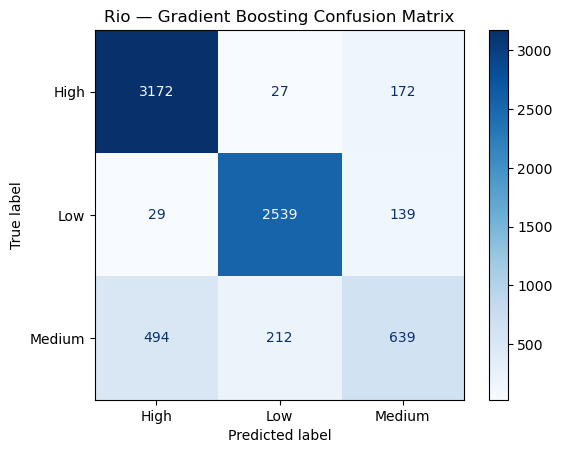

In [20]:
train_preds_rio = gb_rio.predict(X_train_rio)
test_preds_rio  = gb_rio.predict(X_test_rio)

print(f"Train Acc: {accuracy_score(y_train_rio, train_preds_rio):.4f} | Test Acc: {accuracy_score(y_test_rio, test_preds_rio):.4f}")
print(f"Train F1:  {f1_score(y_train_rio, train_preds_rio, average='weighted'):.4f} | Test F1: {f1_score(y_test_rio, test_preds_rio, average='weighted'):.4f}")
print(f"\nTest Classification Report:")
print(classification_report(y_test_rio, test_preds_rio))

# Confusion matrix
cm   = confusion_matrix(y_test_rio, test_preds_rio, labels=np.unique(y_test_rio))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test_rio))
disp.plot(cmap='Blues')
plt.title("Rio — Gradient Boosting Confusion Matrix")
plt.grid(False)
plt.show()

#### Feature importance

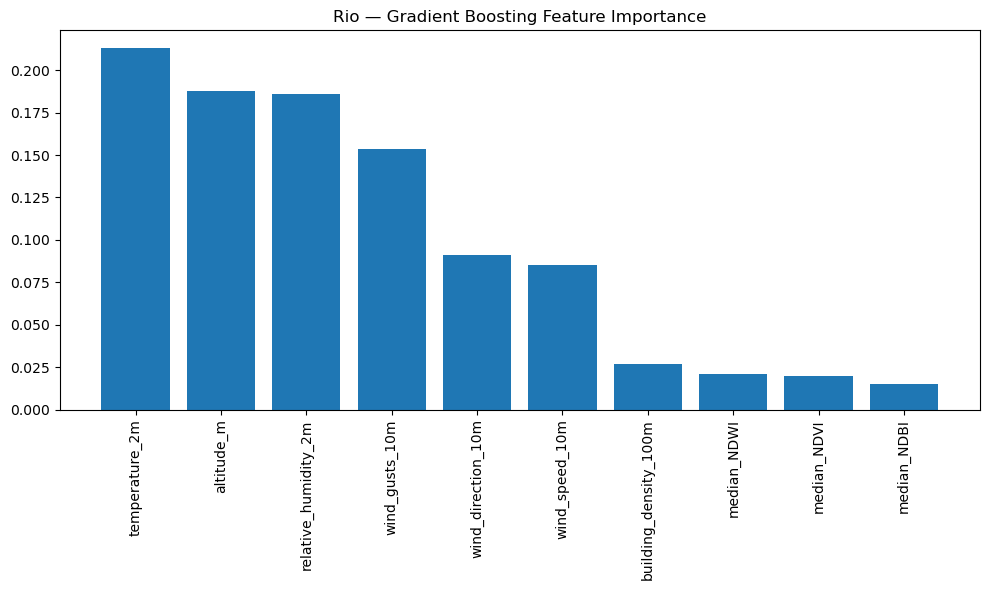

In [21]:
feature_names_rio = train_rio.drop(columns=['UHI_Class']).columns
importances_rio   = gb_rio.feature_importances_
indices_rio       = np.argsort(importances_rio)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Rio — Gradient Boosting Feature Importance")
plt.bar(range(len(importances_rio)), importances_rio[indices_rio], align='center')
plt.xticks(range(len(importances_rio)), feature_names_rio[indices_rio], rotation=90)
plt.tight_layout()
plt.show()

#### Save Predictions
> `Predicted_Dataset_Rio.csv`

In [ ]:
rio_feature_cols   = train_rio.drop(columns=['UHI_Class']).columns.tolist()
X_rio_full         = rio_uhi_data_clean[rio_feature_cols].values.astype(float)
X_rio_full_scaled  = sc_rio.transform(X_rio_full)
rio_full_preds     = gb_rio.predict(X_rio_full_scaled)

pd.DataFrame({
    'Longitude': rio_uhi_data_clean['Longitude'].values,
    'Latitude':  rio_uhi_data_clean['Latitude'].values,
    'UHI_Class': rio_full_preds
}).to_csv(f"{OUTPUT_PATH}/Predicted_Dataset_Rio.csv", index=False)

print("Saved: Predicted_Dataset_Rio.csv")


### **Prediction: Freetown, Sierra Leone**

Unlike Chile and Rio, where we trained and tested within the same city, Freetown required us to generalize patterns learned elsewhere to an entirely new urban environment. Our first attempts used models trained on Chile and Rio individually, but both failed badly: each model simply predicted whichever class dominated its training city, confirming that single-source training produces geographically biased models. This led us to combine Chile and Rio into a single training dataset, reasoning that exposure to two different urban contexts would produce more balanced predictions.

A significant methodological shift came when we moved from single-scene GeoTIFF images to median composites built from multiple Sentinel-2 acquisitions filtered for cloud cover. We also realized that our original spectral features were insufficient; NDVI, NDBI, and NDWI alone could not distinguish the nuances of Freetown's urban fabric. This pushed us to progressively enrich our feature set, first adding Red Edge indices and soil-specific bands, then incorporating Land Surface Temperature and emissivity from Landsat, the two features that ultimately had the greatest impact, since they measure heat directly rather than inferring it from surface proxies. Each addition produced measurable improvement.

The final realization came from examining the professor's returned evaluation results, which revealed Freetown's actual class distribution. We used this to resample our training data to better reflect that reality, which produced our strongest result. The journey from our first submission at 0.30 to our final model at 0.46 was driven by specific diagnostic findings rather than arbitrary experimentation.


#### Load combined dataset for Freetown prediction

In [ ]:
train_df_final = pd.read_csv(f"{lakehouse_path}/train_df_final.csv")
train_df_final.rename(columns={'UHI_Class': 'Target'}, inplace=True)
train_df_final["Target"] = train_df_final["Target"].map({"Low": 0, "Medium": 1, "High": 2})

drop_columns = ['Longitude', 'Latitude', 'date', 'geometry', 'city', 'year']
train_df_final.drop(columns=drop_columns, inplace=True, errors='ignore')

test_df_final = pd.read_csv(f"{lakehouse_path}/test_df_final.csv")
test_df_final_coords = test_df_final[['Longitude', 'Latitude']].copy()
test_df_final.drop(columns=drop_columns, inplace=True, errors='ignore')

print(f"Train shape: {train_df_final.shape}")
print(f"Test shape:  {test_df_final.shape}")
print(f"Class distribution:\n{train_df_final['Target'].value_counts()}")

#### Define feature set

In [ ]:
features_to_use = [
    'building_density_100m',
    'median_NDVI',  'median_NDBI',  'median_NDWI',
    'median_EVI',   'median_SAVI',  'median_BSI',
    'median_RENDVI','median_CIRE',  'median_NDRE',
    'median_NDMI',  'median_BSI2',  'median_NDVI_narrow',
    'lst_celsius',  'emissivity',   'utfvi'
]

# UTFVI — Urban Thermal Field Variance Index
lst_mean = train_df_final['lst_celsius'].mean()
train_df_final['utfvi'] = (train_df_final['lst_celsius'] - lst_mean) / (lst_mean + 1e-10)
test_df_final['utfvi']  = (test_df_final['lst_celsius']  - lst_mean) / (lst_mean + 1e-10)

print(f"Features: {features_to_use}")

#### Resample Data to Match Freetown Ground Truth Distribution

In [ ]:
# Aproximate ground truth from professor evaluation:
# High: 36.1% | Medium: 42.5% | Low: 21.4%

high   = train_df_final[train_df_final['Target'] == 2]
medium = train_df_final[train_df_final['Target'] == 1]
low    = train_df_final[train_df_final['Target'] == 0]

total         = len(train_df_final)
target_high   = int(total * 0.36)
target_medium = int(total * 0.425)
target_low    = int(total * 0.214)

train_resampled = pd.concat([
    resample(high,   n_samples=target_high,   random_state=42),
    resample(medium, n_samples=target_medium, random_state=42),
    resample(low,    n_samples=target_low,    random_state=42)
]).reset_index(drop=True)

print(f"Resampled distribution:")
print(train_resampled['Target'].value_counts())

#### Train/test split on resampled data

In [ ]:
X_res = train_resampled[features_to_use].fillna(0)
y_res = train_resampled['Target']

X_train_res, X_val_res, y_train_res, y_val_res = train_test_split(
    X_res, y_res, stratify=y_res, test_size=0.3, random_state=42
)

print(f"X_train shape: {X_train_res.shape}")
print(f"Class distribution: {y_train_res.value_counts().to_dict()}")

#### Model Training (LGBM)

In [ ]:
lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=-1,
    num_leaves=255,
    learning_rate=0.05,
    min_child_samples=5,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

lgbm_model.fit(X_train_res.fillna(0), y_train_res)

#### Internal evaluation

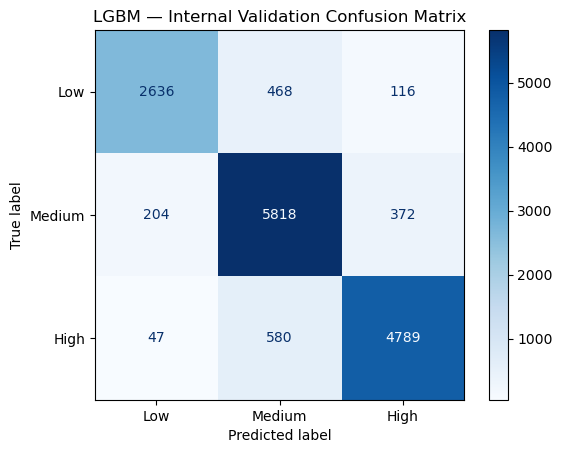

In [28]:
label_map  = {0: "Low", 1: "Medium", 2: "High"}

y_pred_val = lgbm_model.predict(X_val_res.fillna(0))
val_f1     = f1_score(y_val_res, y_pred_val, average='macro')

print(f"Internal Macro F1: {val_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val_res, y_pred_val,
                             target_names=['Low', 'Medium', 'High']))

cm   = confusion_matrix(y_val_res, y_pred_val)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title('LGBM — Internal Validation Confusion Matrix')
plt.grid(False)
plt.show()

#### Feature importance

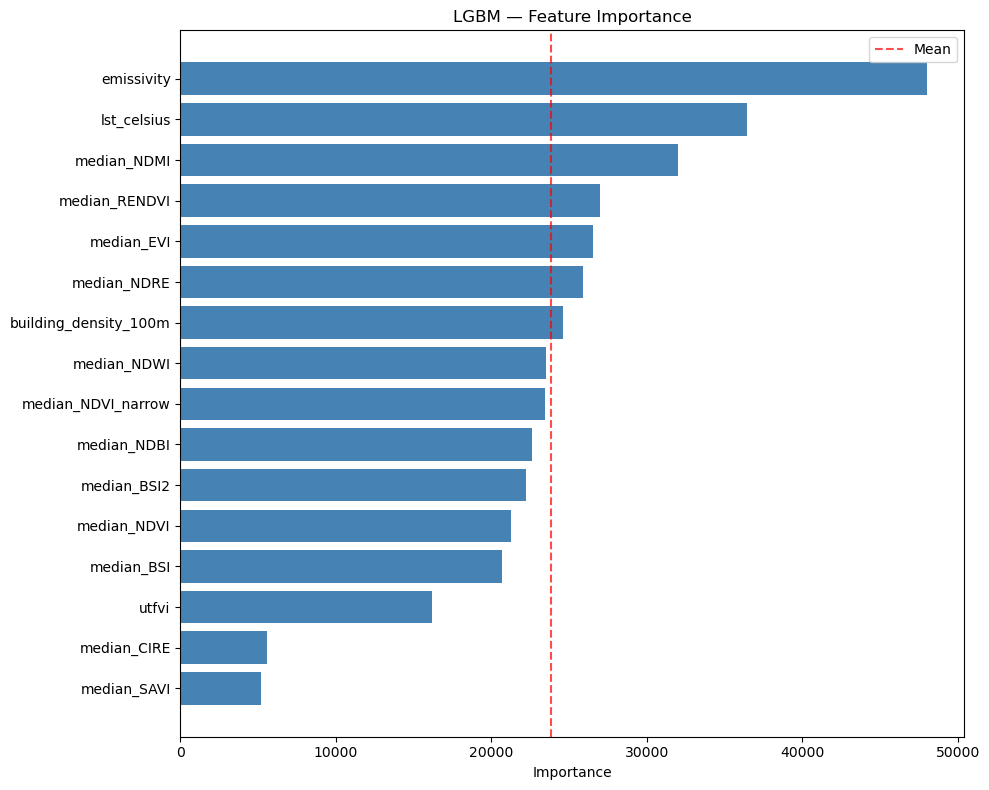

In [29]:
imp_df = pd.DataFrame({
    'feature':    features_to_use,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
plt.axvline(x=imp_df['importance'].mean(), color='red',
            linestyle='--', alpha=0.7, label='Mean')
plt.title('LGBM — Feature Importance')
plt.xlabel('Importance')
plt.legend()
plt.tight_layout()
plt.show()

#### Predict on Freetown

In [ ]:
freetown_X      = test_df_final[features_to_use].fillna(0)
freetown_preds  = lgbm_model.predict(freetown_X)
freetown_labels = pd.Series(freetown_preds).map(label_map).values

print("Freetown prediction distribution:")
print(pd.Series(freetown_labels).value_counts())
print(f"\nHigh %:   {pd.Series(freetown_labels).value_counts()['High']/len(freetown_labels)*100:.1f}%")
print(f"Low %:    {pd.Series(freetown_labels).value_counts()['Low']/len(freetown_labels)*100:.1f}%")
print(f"Medium %: {pd.Series(freetown_labels).value_counts()['Medium']/len(freetown_labels)*100:.1f}%")

#### Save Predictions
> `Predicted_Dataset_Freetown.csv`

In [ ]:
pd.DataFrame({
    'Longitude': test_df_final_coords['Longitude'].values,
    'Latitude':  test_df_final_coords['Latitude'].values,
    'UHI_Class': freetown_labels
}).to_csv(f"{OUTPUT_PATH}/Predicted_Dataset_Freetown.csv", index=False)

print("Saved: Predicted_Dataset_Freetown.csv")

## **IV. Conclusion**

The dominant predictors of UHI identified by our model were Land Surface Temperature, emissivity, and NDMI. Beyond adding more green space, the best ways to reduce this in rapidly expanding areas will be by increasing shade coverage, using more porous building materials, and keeping rooftops cool and reflective. All of these can be done at a relatively low cost with high benefits for existing and expanding communities.

At the same time, there are important limitations to acknowledge. The model struggled to correctly transfer weather features such as temperature, humidity, and wind across geographies, as these variables are climate-specific and caused domain shift when applied from Santiago and Rio to Freetown. This led us to rely primarily on spectral indices, LST, and emissivity derived from Sentinel-2 and Landsat imagery, which proved more geographically transferable. These limitations point directly to how the model could be improved in future iterations. Incorporating additional data such as building height from the 3D-GloBFP dataset, population density from WorldPop, and multi-temporal Sentinel-2 composites would allow the model to move from a static snapshot to a more dynamic system. This would make it possible to simulate the impact of urban planning decisions before they are implemented.

Ultimately, this challenge shows that the data and methods needed to map urban heat vulnerability at a neighborhood scale already exist. The key barrier for cities like Freetown, Rio, and Santiago is not technical feasibility, but prioritization. Models like this help make those decisions more transparent and grounded in evidence.


## **V. References**

Li, X., Stringer, L.C., & Dallimer, M. (2022). The impacts of urbanisation and climate change on the urban thermal environment in Africa. Climate, 10(11), 164. https://doi.org/10.3390/cli10110164 

Mustafa, E.K., Liu, G.X., Hassan, A., Damos, M.A., & Tarawally, M. (2020). Predicting of land surface temperature distribution in Freetown City, Sierra Leone by using polynomial curve fitting model. Journal of Geographic Information System, 12, 531–544. https://doi.org/10.4236/jgis.2020.125031 

Over 4% of Summer Mortality in European Cities is Attributable to Urban Heat Islands. (2023, January 2). ISGlobal; Barcelona Institute for Global Health. https://www.isglobal.org/en/-/4-of-summer-mortality-is-attributable-to-urban-heat-islands 

Sovacool, B.K. (2025). Confronting a "silent killer:" reducing vulnerability to extreme heat in urban West Africa with surface cooling technology and climate-resilient roofing. Climatic Change, 178, 212. https://doi.org/10.1007/s10584-025-04061-9 

Srivastava, V.T., Sharma, A., & Jadon, S.S. (2024). A review of the formation, mitigation strategies from 50 years of global urban heat island studies. Environment, Development and Sustainability, 28, 97–114. https://doi.org/10.1007/s10668-024-04966-y 

Kusterer, C. (2025). *sentinel-2-tif: A Python package for Sentinel-2 GeoTIFF generation*. https://chase-kusterer.github.io/projects/s2-tif/ 


## **VI. Challenge Feedback**

#### **Most Valuable Aspects of the Challenge**

The most valuable aspect of this challenge for our team was that it pushed us beyond the structured and guided environment we are used to in our Business Analytics classes, while introducing a problem that clearly exceeded our initial domain knowledge, especially when working with satellite data and urban heat island modeling.

Additionally, the full modeling process, particularly feature engineering and iteration, was highly valuable. Unlike most ML modeling tasks in our program, this challenge required building a model to predict unseen data, which added a new level of difficulty but also reflected a real-world application. Dealing with class imbalance in the UHI categories forced us to think more critically about data distribution and its impact on model performance. Applying techniques like resampling showed us that improving a model is not just about choosing an algorithm, but about really understanding the data behind it.

The challenge ultimately required not just running models, but understanding what drives the outcome and how to represent that in the data. The relatively low benchmark performance encouraged experimentation and step-by-step improvement rather than reliance on a predefined solution. It also required consideration of missing context, such as weather or elevation, which are likely important drivers of urban heat but were not included in the dataset. This helped highlight model limitations and what would be needed to make the predictions more realistic.

Beyond the technical side, the challenge emphasized how such a model could be applied in practice, particularly in urban planning and sustainability. This combination of technical depth and real-world application provided perspectives we would not have encountered otherwise, making the experience especially meaningful and a strong final challenge for the program.

 

#### **Suggested Improvements to the Challenge**

One improvement we would suggest is to make model testing and validation more accessible and faster. Having a quicker way to test different approaches and receive feedback scores, for example through more flexible submission or validation options, would have allowed us to iterate more efficiently and save time while improving our models.

We also felt that the clarity and accessibility of the provided materials could have been improved. While Dr. Killough's campus session helped provide valuable context, the overall scope of the challenge was still difficult to grasp initially. Providing the slide deck alongside the challenge description, along with more guidance or preparation on working with satellite data and interpreting bands and indices, would have supported a quicker understanding of the tasks.

Given the depth of this specialized field and the limited timeframe, additional contextual framing could help us navigate the domain more effectively and extract even more value from the challenge, while still maintaining its learning objective.


## **Appendix**

### Sentinel Satellite Images (Helper Functions)

In [ ]:
# def download_sentinel_geotiff(lower_left, upper_right, time_window, filename, out_dir):
#     bounds = (lower_left[1], lower_left[0], upper_right[1], upper_right[0])

#     print(f"Searching STAC for {filename}...")
#     stac = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
#     search = stac.search(
#         bbox=bounds,
#         datetime=time_window,
#         collections=["sentinel-2-l2a"],
#         query={"eo:cloud_cover": {"lt": 30}},
#     )
#     items = list(search.get_items())
#     print(f"Found {len(items)} scenes.")

#     if not items:
#         raise ValueError("No Sentinel-2 items found.")

#     signed_items = [pc.sign(item) for item in items]

#     data = stac_load(
#         signed_items,
#         bands=["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"],
#         crs="EPSG:4326",
#         resolution=10/111320.0,
#         chunks={"x": 1024, "y": 1024},
#         dtype="uint16",
#         bbox=bounds,
#     )

#     print("Computing median composite...")
#     median = data.median(dim="time").compute().astype("float32")

#     eps = np.float32(1e-6)

#     ndvi        = (median.B08  - median.B04) / (median.B08  + median.B04  + eps)
#     ndbi        = (median.B11  - median.B08) / (median.B11  + median.B08  + eps)
#     ndwi        = (median.B03  - median.B08) / (median.B03  + median.B08  + eps)
#     evi         = 2.5 * (median.B08 - median.B04) / (median.B08 + 6 * median.B04 - 7.5 * median.B02 + 1 + eps)
#     savi        = ((median.B08 - median.B04) / (median.B08 + median.B04 + 0.5 + eps)) * 1.5
#     bsi         = ((median.B11 + median.B04) - (median.B08  + median.B02)) / ((median.B11 + median.B04) + (median.B08  + median.B02) + eps)
#     rendvi      = (median.B07  - median.B05) / (median.B07  + median.B05  + eps)
#     cire        = (median.B07  / (median.B05  + eps)) - 1
#     ndre        = (median.B8A  - median.B05) / (median.B8A  + median.B05  + eps)
#     ndmi        = (median.B8A  - median.B11) / (median.B8A  + median.B11  + eps)
#     bsi2        = ((median.B12 + median.B04) - (median.B08  + median.B02)) / ((median.B12 + median.B04) + (median.B08  + median.B02) + eps)
#     ndvi_narrow = (median.B8A  - median.B04) / (median.B8A  + median.B04  + eps)

#     height = median.sizes["latitude"]
#     width  = median.sizes["longitude"]
#     gt = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], width, height)

#     os.makedirs(out_dir, exist_ok=True)
#     output_path = os.path.join(out_dir, filename)

#     print(f"Saving GeoTIFF to {output_path}...")
#     with rasterio.open(
#         output_path, "w", driver="GTiff",
#         width=width, height=height,
#         crs="EPSG:4326", transform=gt,
#         count=12, compress="lzw", dtype="float32"
#     ) as dst:
#         dst.write(ndvi.values,         1)
#         dst.write(ndbi.values,         2)
#         dst.write(ndwi.values,         3)
#         dst.write(evi.values,          4)
#         dst.write(savi.values,         5)
#         dst.write(bsi.values,          6)
#         dst.write(rendvi.values,       7)
#         dst.write(cire.values,         8)
#         dst.write(ndre.values,         9)
#         dst.write(ndmi.values,        10)
#         dst.write(bsi2.values,        11)
#         dst.write(ndvi_narrow.values, 12)

#     print(f"Saved 12-band GeoTIFF")

# def get_bounds_from_csv(csv_path, padding=0.01):
#     df = pd.read_csv(csv_path)
#     df.columns = [c.strip().lower() for c in df.columns]
#     ln = 'longitude' if 'longitude' in df.columns else 'lon'
#     lt = 'latitude'  if 'latitude'  in df.columns else 'lat'
#     min_lon, max_lon = df[ln].min() - padding, df[ln].max() + padding
#     min_lat, max_lat = df[lt].min() - padding, df[lt].max() + padding
#     return (min_lat, min_lon), (max_lat, max_lon)


# def visualize_geotiff(tiff_path, city_name):
#     """
#     Reads a 12-band GeoTIFF and generates index maps for all bands.
#     Band order: NDVI, NDBI, NDWI, EVI, SAVI, BSI, RENDVI, CIRE, NDRE, NDMI, BSI2, NDVI_narrow
#     """
#     import rasterio

#     with rasterio.open(tiff_path) as src:
#         ndvi        = src.read(1)
#         ndbi        = src.read(2)
#         ndwi        = src.read(3)
#         evi         = src.read(4)
#         savi        = src.read(5)
#         bsi         = src.read(6)
#         rendvi      = src.read(7)
#         cire        = src.read(8)
#         ndre        = src.read(9)
#         ndmi        = src.read(10)
#         bsi2        = src.read(11)
#         ndvi_narrow = src.read(12)

#     # Band definitions: (data, vmin, vmax, cmap, title)
#     bands = [
#         (ndvi,        0.0,  0.8,  'RdYlGn', 'NDVI'),
#         (ndbi,       -0.1,  0.04, 'jet',    'NDBI'),
#         (ndwi,       -0.4,  0.2,  'RdBu',   'NDWI'),
#         (evi,         0.0,  0.8,  'RdYlGn', 'EVI'),
#         (savi,        0.0,  0.8,  'RdYlGn', 'SAVI'),
#         (bsi,        -0.5,  0.5,  'YlOrBr', 'BSI'),
#         (rendvi,      0.0,  0.8,  'RdYlGn', 'RENDVI'),
#         (cire,        0.0,  5.0,  'RdYlGn', 'CIRE'),
#         (ndre,       -0.2,  0.6,  'RdYlGn', 'NDRE'),
#         (ndmi,       -0.4,  0.4,  'RdBu',   'NDMI'),
#         (bsi2,       -0.5,  0.5,  'YlOrBr', 'BSI2'),
#         (ndvi_narrow, 0.0,  0.8,  'RdYlGn', 'NDVI Narrow'),
#     ]

#     fig, axes = plt.subplots(3, 4, figsize=(24, 16))
#     axes = axes.flatten()
#     fig.suptitle(f'{city_name} — Spectral Indices', fontsize=16, y=1.02)

#     for i, (data, vmin, vmax, cmap, title) in enumerate(bands):
#         im = axes[i].imshow(data, vmin=vmin, vmax=vmax, cmap=cmap)
#         axes[i].set_title(f'{city_name} — Median {title}', fontsize=11)
#         axes[i].axis('off')
#         plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

#     plt.tight_layout()
#     plt.show()


# def visualize_landsat(tiff_path, city_name):
#     """
#     Reads a 2-band Landsat GeoTIFF and generates maps for LST and Emissivity.
#     Band order: Band 1 = LST (°C), Band 2 = Emissivity
#     """
#     import rasterio

#     with rasterio.open(tiff_path) as src:
#         lst  = src.read(1)
#         emis = src.read(2)

#     fig, axes = plt.subplots(1, 2, figsize=(14, 6))
#     fig.suptitle(f'{city_name} — Landsat Thermal Features', fontsize=16, y=1.02)

#     # LST
#     im0 = axes[0].imshow(lst, cmap='RdYlBu_r', vmin=20, vmax=55)
#     axes[0].set_title(f'{city_name} — Land Surface Temperature (°C)', fontsize=11)
#     axes[0].axis('off')
#     plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='°C')

#     # Emissivity
#     im1 = axes[1].imshow(emis, cmap='RdYlGn', vmin=0.97, vmax=1.0)
#     axes[1].set_title(f'{city_name} — Emissivity', fontsize=11)
#     axes[1].axis('off')
#     plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

#     plt.tight_layout()
#     plt.show()


# def visualize_rgb_composite(lower_left, upper_right, time_window, city_name):
#     """
#     Downloads Sentinel-2 data and generates an RGB Median Composite image.
#     """
#     bounds = (lower_left[1], lower_left[0], upper_right[1], upper_right[0])

#     stac = pystac_client.Client.open('https://planetarycomputer.microsoft.com/api/stac/v1')
#     search = stac.search(
#         bbox=bounds,
#         datetime=time_window,
#         collections=['sentinel-2-l2a'],
#         query={'eo:cloud_cover': {'lt': 30}},
#     )
#     items = list(search.get_items())
#     signed_items = [pc.sign(item) for item in items]

#     data = stac_load(
#         signed_items,
#         bands=['B02', 'B03', 'B04'],
#         crs='EPSG:4326',
#         resolution=10/111320.0,
#         chunks={'x': 1024, 'y': 1024},
#         dtype='uint16',
#         bbox=bounds,
#     )

#     median = data.median(dim='time').compute().astype('float32')

#     rgb = np.stack([median.B04.values, median.B03.values, median.B02.values], axis=-1)
#     rgb = np.clip(rgb, 0, 2500) / 2500.0

#     fig, ax = plt.subplots(figsize=(6, 6))
#     ax.imshow(rgb)
#     ax.set_title(f'{city_name} — RGB Median Composite', fontsize=13)
#     ax.axis('off')
#     plt.tight_layout()
#     plt.show()

### Santiago (Chile)
Time Window: January 13–30, 2024

In [ ]:
# # Santiago — RGB Median Composite
# ll_chile, ur_chile = get_bounds_from_csv(chile_csv_url)
# visualize_rgb_composite(ll_chile, ur_chile, '2024-01-13/2024-01-30', 'Santiago')

### Rio de Janeiro (Brazil)
Time Window: January 1–31, 2023

In [ ]:
# # Rio — RGB Median Composite
# ll_brazil, ur_brazil = get_bounds_from_csv(brazil_csv_url)
# visualize_rgb_composite(ll_brazil, ur_brazil, '2022-10-01/2023-03-31', 'Rio de Janeiro')

### Freetown (Sierra Leone)
Time Window: January 20–30, 2023

In [ ]:
# # Freetown — RGB Median Composite
# ll_sl, ur_sl = get_bounds_from_csv(test_csv_url)
# visualize_rgb_composite(ll_sl, ur_sl, '2023-01-20/2023-01-30', 'Freetown')

### Sentinel-2 spectral indices

In [ ]:
# # Sentinel-2 spectral indices
# visualize_geotiff(f"{lakehouse_path}/sample_chile.tiff",          "Santiago")
# visualize_geotiff(f"{lakehouse_path}/sample_brazil.tiff",         "Rio de Janeiro")
# visualize_geotiff(f"{lakehouse_path}/sierra_leone_test.tiff",     "Freetown")

### Landsat LST + Emissivity

In [ ]:
# # Landsat LST + Emissivity
# visualize_landsat(f"{lakehouse_path}/lst_chile.tiff",             "Santiago")
# visualize_landsat(f"{lakehouse_path}/lst_brazil.tiff",            "Rio de Janeiro")
# visualize_landsat(f"{lakehouse_path}/lst_sierra_leone.tiff",      "Freetown")